In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data_df = pd.read_csv('data.csv')
data_df = data_df.dropna(subset=['Count'])
data_df

,Date,Name,Count,Point
0,2025-06-01,Аманн,0,БЛУМ
1,2025-06-02,Аманн,0,БЛУМ
2,2025-06-03,Аманн,0,БЛУМ
3,2025-06-04,Аманн,0,БЛУМ
4,2025-06-05,Аманн,0,БЛУМ
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5,СПЕЦ_26


In [3]:
data_df[data_df['Name'] == 'Бабка корица и карамель']

,Date,Name,Count,Point
276,2025-06-01,Бабка корица и карамель,2,БЛУМ
277,2025-06-02,Бабка корица и карамель,1,БЛУМ
278,2025-06-03,Бабка корица и карамель,1,БЛУМ
279,2025-06-04,Бабка корица и карамель,1,БЛУМ
280,2025-06-05,Бабка корица и карамель,1,БЛУМ
...,...,...,...,...
44613,2026-07-20,Бабка корица и карамель,1,СПЕЦ_26
44623,2026-07-30,Бабка корица и карамель,3,СПЕЦ_26
44624,2026-07-31,Бабка корица и карамель,3,СПЕЦ_26
44625,2026-08-01,Бабка корица и карамель,1,СПЕЦ_26


In [4]:
data_df['Date'] = pd.to_datetime(data_df['Date'], errors='coerce')
data_df['Date'].dtype

dtype('<M8[ns]')

In [5]:
data_df['Count'] = pd.to_numeric(data_df['Count'], errors='coerce').fillna(0)

In [6]:
df_2026 = data_df[data_df['Date'].dt.year == 2026].copy()
df_2026

,Date,Name,Count,Point
19399,2026-06-01,Аманн,10.0,ЦЕХ_2026
19400,2026-06-02,Аманн,10.0,ЦЕХ_2026
19401,2026-06-03,Аманн,10.0,ЦЕХ_2026
19402,2026-06-04,Аманн,12.0,ЦЕХ_2026
19403,2026-06-05,Аманн,20.0,ЦЕХ_2026
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8.0,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2.0,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2.0,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5.0,СПЕЦ_26


In [7]:
point_sales = df_2026.groupby('Point')['Count'].sum().sort_values(ascending=False)
print("--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---")
print(point_sales)
print(f"Всего: {df_2026['Count'].sum()}")
print("\n" + "="*60 + "\n")

--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---
Point
СПИРИ_26      19352.0
ЦЕХ_2026      12452.0
ЧАПА_26        7274.0
КИТЧЕН         5383.0
ВЯТСКАЯ_26     1437.0
СПЕЦ_26         489.0
ODMO_26         275.0
Name: Count, dtype: float64
Всего: 46662.0




In [8]:
print("--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---")
top_by_point = df_2026.groupby(['Point', 'Name'])['Count'].sum().reset_index()
top_by_point = top_by_point.sort_values(['Point', 'Count'], ascending =[True, False])
print(top_by_point.groupby('Point').head(3).to_string(index=False))

--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---
     Point                                   Name  Count
   ODMO_26                                  Аманн  105.0
   ODMO_26                           Круассан 75г   94.0
   ODMO_26                     Булка с кардамоном   54.0
ВЯТСКАЯ_26 Кекс шоколад с кремом вареная сгущенка  438.0
ВЯТСКАЯ_26                                  Аманн  332.0
ВЯТСКАЯ_26                     Булка с кардамоном  317.0
    КИТЧЕН                        Кунжутная булка  948.0
    КИТЧЕН                           Круассан 75г  731.0
    КИТЧЕН                                  Багет  696.0
   СПЕЦ_26                     Булка с кардамоном   79.0
   СПЕЦ_26                        Булка с корицей   70.0
   СПЕЦ_26                                  Аманн   68.0
  СПИРИ_26                              Бейгл 100 1547.0
  СПИРИ_26                          Булка с маком 1442.0
  СПИРИ_26                      Печенье для собак 1020.0
  ЦЕХ_2026                           

Деление (Финальный средний балл): Полученную сумму он делит на общее количество строк, которые попали в этот фильтр.
$$ \text{Среднее значение ячейки} = \frac{\text{Сумма всех продаж для дня недели на точке}}{\text{Количество строк для дня недели на точке}} $$


In [9]:
print(" ---3. Сезонность в какие дни больше продаётся")
df_2026['Day_of_week'] = df_2026['Date'].dt.day_name()
weekly_pattern = df_2026.pivot_table(
    index = 'Day_of_week',
    columns='Point',
    values='Count',
    aggfunc='mean'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

print(weekly_pattern)

 ---3. Сезонность в какие дни больше продаётся
Point         ODMO_26  ВЯТСКАЯ_26    КИТЧЕН    СПЕЦ_26   СПИРИ_26   ЦЕХ_2026  \
Day_of_week                                                                    
Monday       2.700000    4.645833  4.274809   4.500000   8.014368   8.425806   
Tuesday      3.818182    5.411765  4.184615   6.333333   9.729885   9.449612   
Wednesday    2.750000    4.111111  4.322034  10.230769   6.924242   8.608392   
Thursday     3.083333    4.625000  4.207692  10.000000   7.410774   9.906977   
Friday       2.600000    5.950000  6.133333   5.333333   9.714706  10.853147   
Saturday     3.583333    3.857143  8.734266   5.115385  11.013245  21.035714   
Sunday       2.866667    4.867925  8.807692   4.400000   9.227106  22.820312   

Point         ЧАПА_26  
Day_of_week            
Monday       2.020000  
Tuesday      4.424528  
Wednesday    4.772512  
Thursday     5.023697  
Friday       5.585253  
Saturday     6.179724  
Sunday       5.580645  


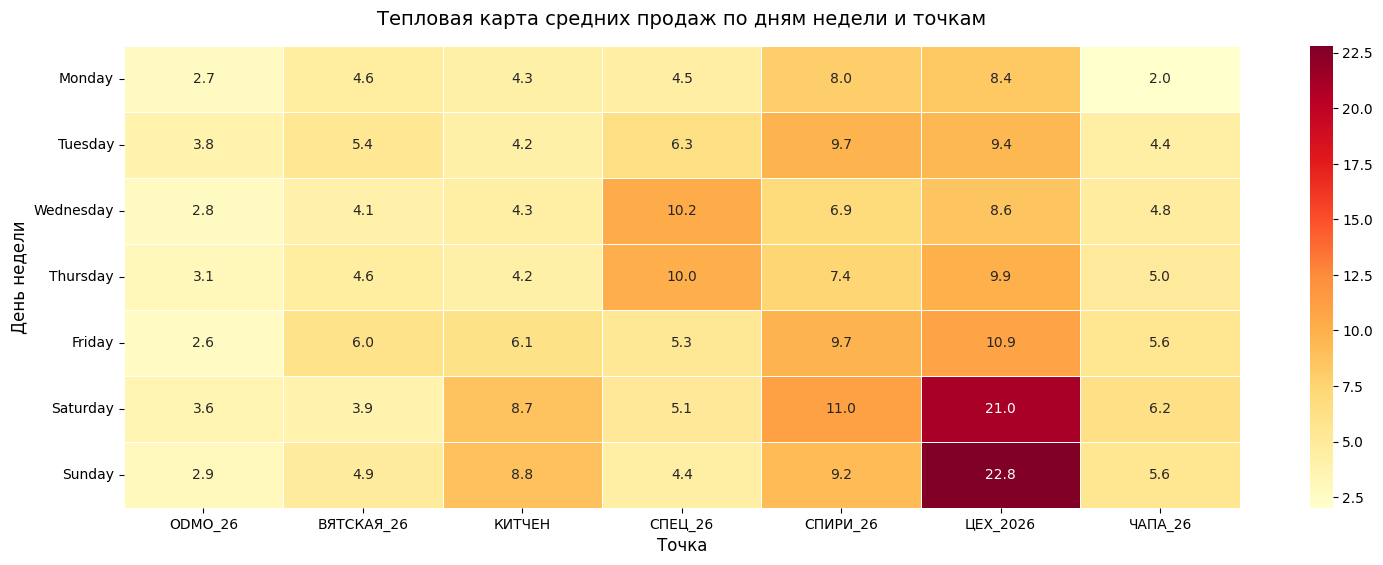

In [10]:
plt.figure(figsize=(18, 6))
sns.heatmap(weekly_pattern, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Тепловая карта средних продаж по дням недели и точкам', fontsize=14, pad=15)
plt.ylabel('День недели', fontsize=12)
plt.xlabel('Точка', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\1973859364.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')


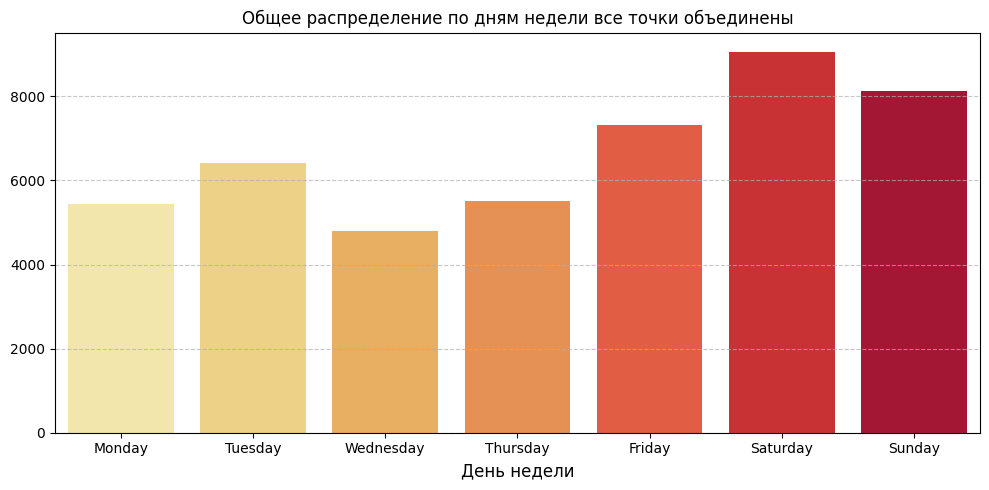

In [11]:
weekly_total = df_2026.groupby('Day_of_week')['Count'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

plt.figure(figsize=(10, 5))

sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')
plt.title('Общее распределение по дням недели все точки объединены', fontsize=12)
plt.xlabel('День недели', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

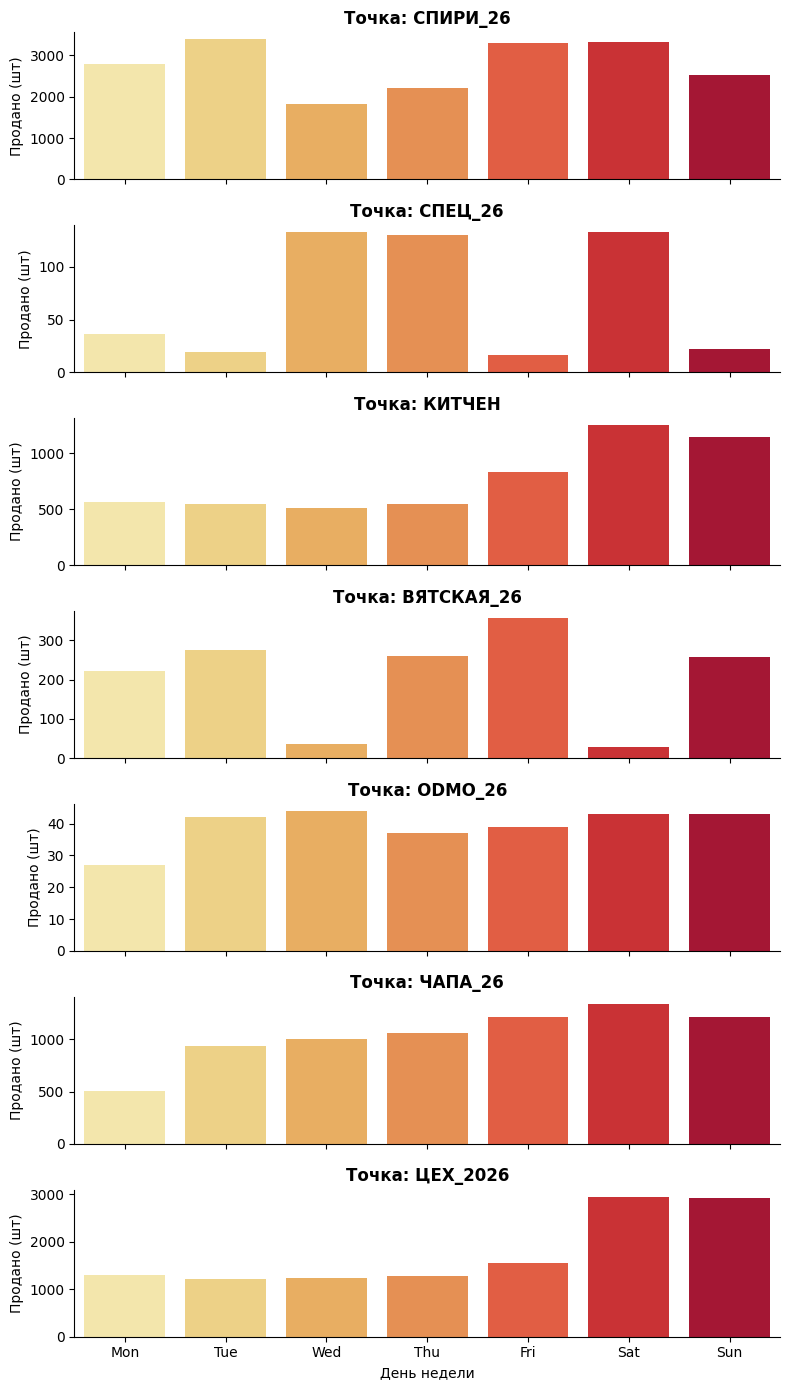

In [12]:
# 1. Считаем сумму продаж для каждого сочетания Точка + День недели
df_grouped = df_2026.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=False)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

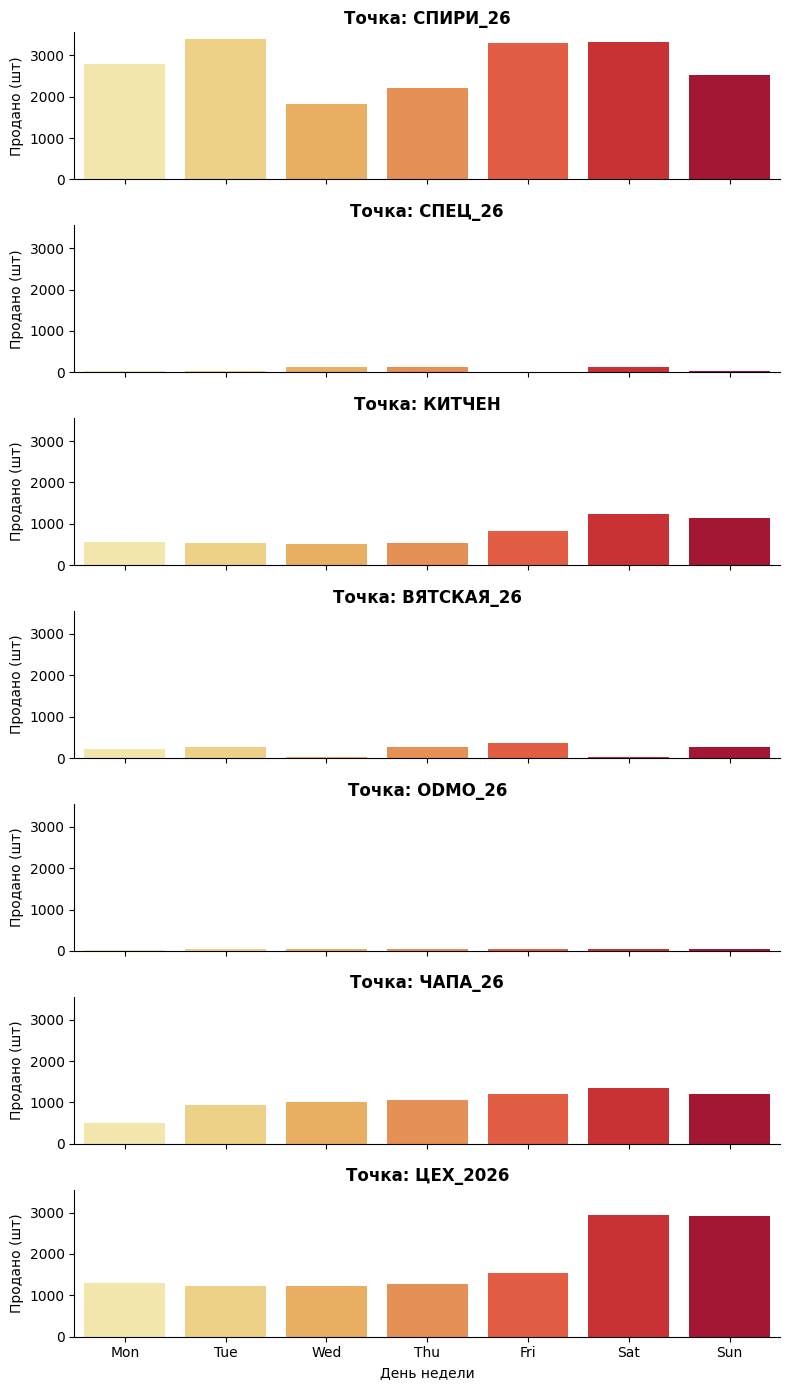

In [13]:

df_grouped = df_2026.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=True)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

Мы проверям насколько данные однородны.  
Допустим у нас есть какая то позиция, которая продаётся в один магазин, в большом колличестве (например печенье)
Если такие позиции имеются, без фильтрации данных сложнее интерпретировать графики связанные с общим колличеством всех товаров

In [14]:
product_totals = df_2026.groupby('Name')['Count'].sum().sort_values(ascending=False).to_frame()

total_volume = product_totals['Count'].sum()
product_totals['Share_%'] = (product_totals['Count'] / total_volume) * 100
product_totals['Cumulative_Share_%'] = product_totals['Share_%'].cumsum()
print('TOP 10 по общему объему')
print(product_totals.head(10).to_string())

max_item = product_totals['Count'].max()
median_item = product_totals['Count'].median()
anomaly_ratio = max_item / median_item if median_item > 0 else 0

print(f"Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в {anomaly_ratio:.1f})")

if anomaly_ratio > 50:
    print("КРАЙНЕ НЕОДНОРОДНА")
else:
    print("Структура данных однородна")

TOP 10 по общему объему
                     Count   Share_%  Cumulative_Share_%
Name                                                    
Бейгл 100           4009.0  8.591573            8.591573
Аманн               3533.0  7.571471           16.163045
Булка с маком       3317.0  7.108568           23.271613
Морнинг бан жасмин  2300.0  4.929064           28.200677
Круассан 75г        2224.0  4.766191           32.966868
Булка с кардамоном  1833.0  3.928250           36.895118
Паштель де ната     1767.0  3.786807           40.681925
Багет               1722.0  3.690369           44.372294
Булка с тхиной      1588.0  3.403197           47.775492
Булка с корицей     1464.0  3.137457           50.912948
Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в 12.4)
Структура данных однородна


In [15]:
categories_df = pd.read_csv('categories.csv')
categories_df

,Name,Category,Status
0,Аманн,Выпечка,Активный
1,Аманн Черный кунжут,Выпечка,Снят
2,Бабка Кардамон,Выпечка,Снят
3,Бабка Корица,Выпечка,Снят
4,Бабка корица и карамель,Выпечка,Активный
...,...,...,...
193,Квашеная капуста пф,Полуфабрикаты,пф
194,Ханни баттер тост,Выпечка,Снят
195,Хани баттер тост,Выпечка,Cнят
196,Морнинг бан жасмин,Выпечка,Активный


In [16]:
df_2026 = pd.merge(df_2026, categories_df, on='Name', how='left')
df_2026

,Date,Name,Count,Point,Day_of_week,Category,Status
0,2026-06-01,Аманн,10.0,ЦЕХ_2026,Monday,Выпечка,Активный
1,2026-06-02,Аманн,10.0,ЦЕХ_2026,Tuesday,Выпечка,Активный
2,2026-06-03,Аманн,10.0,ЦЕХ_2026,Wednesday,Выпечка,Активный
3,2026-06-04,Аманн,12.0,ЦЕХ_2026,Thursday,Выпечка,Активный
4,2026-06-05,Аманн,20.0,ЦЕХ_2026,Friday,Выпечка,Активный
...,...,...,...,...,...,...,...
6265,2026-07-04,Фокачча 400х600,8.0,СПЕЦ_26,Saturday,Хлеб,пф
6266,2026-07-18,Фокачча 400х600,2.0,СПЕЦ_26,Saturday,Хлеб,пф
6267,2026-07-04,Фокачча GN 2/3,2.0,СПЕЦ_26,Saturday,Хлеб,Снят
6268,2026-07-09,Морнинг бан жасмин,5.0,СПЕЦ_26,Thursday,Выпечка,Активный


In [17]:
# 1. Сначала убираем ошибочную строку с названием точки
df_2026 = df_2026[df_2026['Name'] != 'Краснопролетарская (студио)']

# 2. Прописываем категории для всех новинок 2026 года
df_2026.loc[df_2026['Name'] == 'Бабка карамелизированный шоколад и кокос', 'Category'] = 'Булки'
df_2026.loc[df_2026['Name'] == 'Бейгл 120', 'Category'] = 'Хлеб'  # либо 'Выпечка', если бейглы у вас там
df_2026.loc[df_2026['Name'] == 'Бриошь с ванильным кремом в ягодной глазури', 'Category'] = 'Булки'
df_2026.loc[df_2026['Name'] == 'Ватрушка брусника-ваниль', 'Category'] = 'Булки'
df_2026.loc[df_2026['Name'] == 'Даниш Баннофи', 'Category'] = 'Выпечка'
df_2026.loc[df_2026['Name'] == 'Кекс лимон-малина', 'Category'] = 'Десерты'
df_2026.loc[df_2026['Name'] == 'Круассан с кремом и компоте', 'Category'] = 'Выпечка'
df_2026.loc[df_2026['Name'] == 'Мини даниш с курдом', 'Category'] = 'Выпечка'
df_2026.loc[df_2026['Name'] == 'Шу мини жасмин', 'Category'] = 'Десерты'
df_2026.loc[df_2026['Name'] == 'Шу мини малина-ваниль', 'Category'] = 'Десерты'
df_2026.loc[df_2026['Name'] == 'Шу мини earl grey', 'Category'] = 'Десерты'
df_2026.loc[df_2026['Name'] == 'Гранола грецкий орех-клюква', 'Category'] = 'Полуфабрикаты'
df_2026.loc[df_2026['Name'] == 'Амман с цедрой лайма', 'Category'] = 'Выпечка'
df_2026.loc[df_2026['Name'] == 'Honey butter toast', 'Category'] = 'Выпечка'

# 3. На всякий случай проверяем, что у нас не осталось товаров с пустой категорией (NaN)
df_2026['Category'] = df_2026['Category'].dropna()

print("Все новинки успешно разнесены по правильным категориям!")


Все новинки успешно разнесены по правильным категориям!


У некоторых данных есть опечатки в названиях !!!!хани баттер, морнинг бан жасмин

In [18]:
missing_categories = df_2026[df_2026['Category'].isna()]['Name'].unique()

if len(missing_categories) > 0:
    print(missing_categories)

In [19]:
# df_clean = df_2025.groupby('Category')['Name'].unique().explode().reset_index()
df_clean = df_2026.groupby(['Name', 'Category'])['Count'].sum().reset_index()
df_clean = df_clean[df_clean['Count'] > 0]
# df_clean = df_clean.groupby('Category')['Name'].unique().explode().reset_index()
pd.set_option('display.max_rows', None)
df_clean


,Name,Category,Count
0,Аманн,Выпечка,3533.0
1,Бабка Кардамон,Выпечка,1.0
2,Бабка Корица,Выпечка,88.0
3,Бабка Мак,Выпечка,251.0
4,Бабка корица и карамель,Выпечка,307.0
5,Багет,Хлеб,1722.0
6,Бейгл 100,Булки,4009.0
7,Бородинский хлеб,Хлеб,206.0
8,Бриошь 10х10,Хлеб,24.0
9,Бриошь ревень-клубника,Булки,791.0


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\1144295885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')


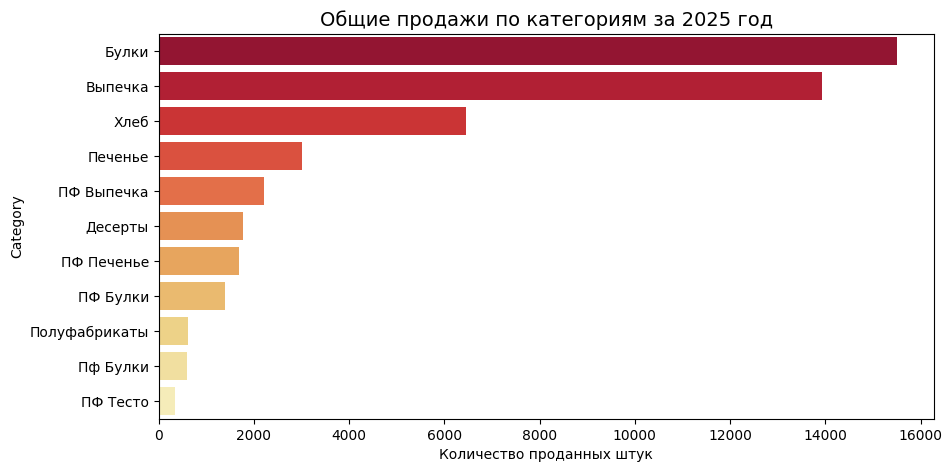

In [ ]:
# Строим график объемов продаж по категориям товаров
plt.figure(figsize=(10, 5))
category_sales = df_2026.groupby('Category')['Count'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')
plt.title('Общие продажи по категориям за 2026 год', fontsize=14)
plt.xlabel('Количество проданных штук')
plt.show()


### Комментарий по поводу категорий 2025 года
Две категории состоят по факту из одной позиции, которая мало продавалась в течении лета 2025
1. **Продукт**
2. **Еда**

Также, категории **Полуфабрикаты** в больщую часть состоят из товаров, которые заказывались в последние недели августа  

### Что означает нормировка в данном анализе?

В данном блоке кода под **нормированием** понимается переход от *абсолютных показателей* (количество проданных штук) к *относительным* (доля товара внутри своей товарной категории).

**Зачем это нужно:**
1. **Устранение масштаба категорий:** Это позволяет корректно сравнивать крупногабаритные/дорогие товары (где продаются единицы) с мелким масс-маркетом (где продаются тысячи штук).
2. **Оценка рыночной силы:** Мы видим не просто сухие цифры продаж, а реальный вклад каждого товара в успех его конкретного отдела. 

**Пример логики расчета:**
* Суммируются продажи абсолютно всех товаров внутри категории `Х` (это базовые 100%).
* Продажи конкретного товара `А` делятся на эту общую сумму категории и умножаются на 100.
* **Результат:** Мы находим, какой процент от общего «пирога» категории забрал себе данный товар. ТОП-3 показывает главных локомотивов каждой категории.


In [21]:
# 1. Считаем общие продажи каждого товара за 2025 год
product_sales = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()

# 2. Магия Pandas: делим продажи товара на сумму продаж ВСЕЙ его категории (через transform)
product_sales['Доля_в_категории_%'] = (
    product_sales['Count'] / product_sales.groupby('Category')['Count'].transform('sum')
) * 100

# Сортируем для красоты: сначала по категориям, а внутри них — от лидеров к аутсайдерам
product_sales = product_sales.sort_values(['Category', 'Доля_в_категории_%'], ascending=[True, False])

top_3_products = product_sales.groupby('Category').head(3).copy()
styled_table = top_3_products.style\
    .format({'Доля_в_категории_%': '{:.2f}%', 'Count' : '{:,}'})\
    .background_gradient(subset=['Доля_в_категории_%'], cmap='YlGnBu')\
    .background_gradient(subset=['Count'], cmap='Oranges')\
    .set_caption("<b> ТОП-3 товара в каждой категории (нормировано)</b>")\
    .hide(axis='index')

# print("--- ТОП-3 ТОВАРА ВНУТРИ КАЖДОЙ КАТЕГОРИИ (НОРМИРОВАНО) ---")
# print(product_sales.groupby('Category').head(3).to_string(index=False))
styled_table


Category,Name,Count,Доля_в_категории_%
Булки,Бейгл 100,"4,009.0",25.86%
Булки,Булка с маком,"3,317.0",21.40%
Булки,Булка с кардамоном,"1,833.0",11.83%
Выпечка,Аманн,"3,533.0",25.35%
Выпечка,Морнинг бан жасмин,"2,300.0",16.50%
Выпечка,Круассан 75г,"2,224.0",15.96%
Десерты,Паштель де ната,"1,767.0",100.00%
ПФ Булки,ПФ Булка корица,600.0,42.80%
ПФ Булки,ПФ Булка тхина,340.0,24.25%
ПФ Булки,ПФ бейгл 100,270.0,19.26%


Мы видим, что **Пастрами п/ф** занимают 65 % полуфабрикатов, *Чапа* выбила большую часть категории **Полуфабрикаты** 

$$ Доля \ товара = \left( \frac{Число}{Число \ товаров \ во \ всей \ категории} \right) \cdot 100\% $$

<Figure size 1400x800 with 0 Axes>

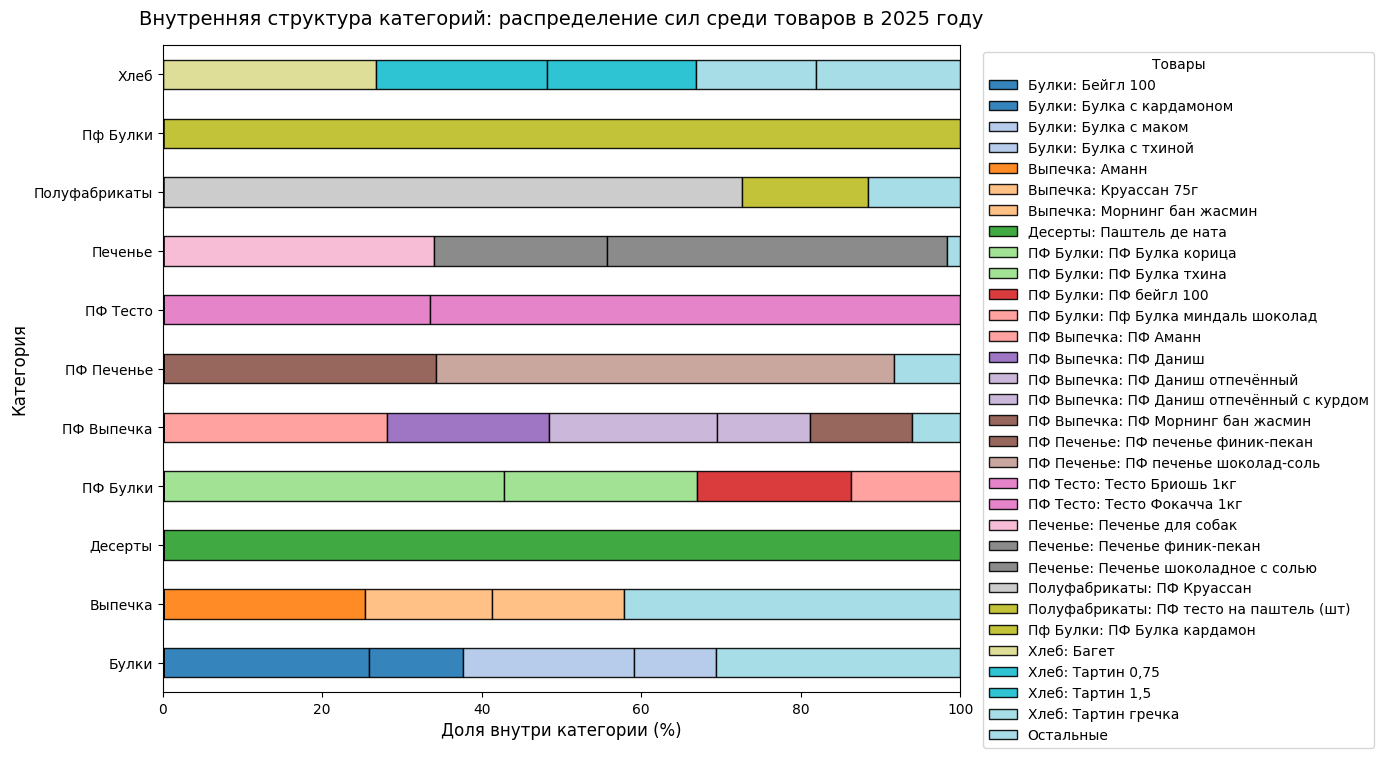

In [22]:
# 1. Считаем продажи и доли товаров внутри категорий
prod_structure = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()
prod_structure['Share_%'] = (prod_structure['Count'] / prod_structure.groupby('Category')['Count'].transform('sum')) * 100

# 2. Схлопываем мелкие товары (< 5% внутри категории) в группу "Остальные", чтобы не было каши
prod_structure.loc[prod_structure['Share_%'] < 10, 'Name'] = 'Остальные'

# --- МАГИЯ: Склеиваем категорию и название товара для легенды ---
# Если товар "Остальные", оставляем просто "Остальные", для остальных — делаем "Категория: Товар"
prod_structure['Category_Product'] = prod_structure.apply(
    lambda row: 'Остальные' if row['Name'] == 'Остальные' 
    else f"{row['Category']}: {row['Name']}", 
    axis=1
)

# Группируем уже по новой склеенной колонке
pivot_structure = prod_structure.groupby(['Category', 'Category_Product'])['Share_%'].sum().unstack().fillna(0)

# Сортируем колонки легенды так, чтобы "Остальные" были в самом конце
if 'Остальные' in pivot_structure.columns:
    cols = [c for c in pivot_structure.columns if c != 'Остальные'] + ['Остальные']
    pivot_structure = pivot_structure[cols]
# 3. Строим горизонтальный 100% график
# Используем большую качественную палитру для множества товаров
plt.figure(figsize=(14, 8))
pivot_structure.plot(kind='barh', stacked=True, figsize=(14, 8), cmap='tab20', edgecolor='black', alpha=0.9)

# Настраиваем оформление
plt.title('Внутренняя структура категорий: распределение сил среди товаров в 2025 году', fontsize=14, pad=15)
plt.xlabel('Доля внутри категории (%)', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.xlim(0, 100)

# Выносим легенду вправо, чтобы она не перекрывала график
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Товары")
plt.tight_layout()
plt.show()


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\2514989247.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Count', y='Name', dodge=False, palette='flare')


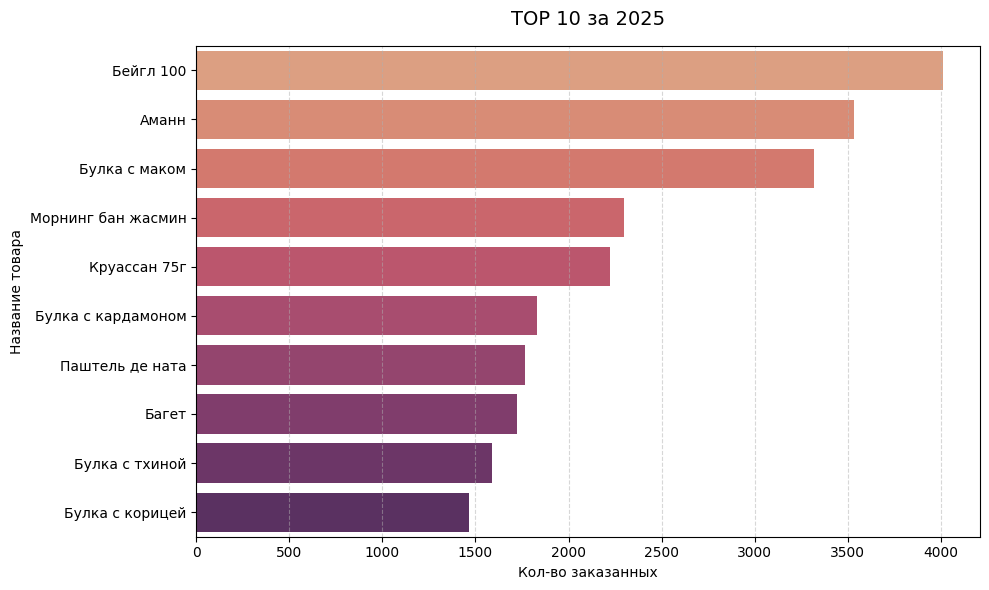

In [23]:
top_products = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()
top_products = top_products.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Count', y='Name', dodge=False, palette='flare')

plt.title('TOP 10 за 2025', fontsize=14, pad=15)
plt.xlabel('Кол-во заказанных')
plt.ylabel('Название товара')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
def plot_counts_in_category(target_category:str):
    category_df = df_2026[df_2026['Category'] == target_category] 
    product_count = category_df.groupby('Name')['Count'].sum().reset_index().sort_values(by='Count', ascending=False)
    product_count = product_count[product_count['Count'] > 0]
    plt.figure(figsize=(10, 5))
    sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')

    plt.title(f'Кол-во товаров в категории "{target_category}"', fontsize=14, pad=15)
    plt.xlabel('Кол-во заказанных')
    plt.ylabel(None)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


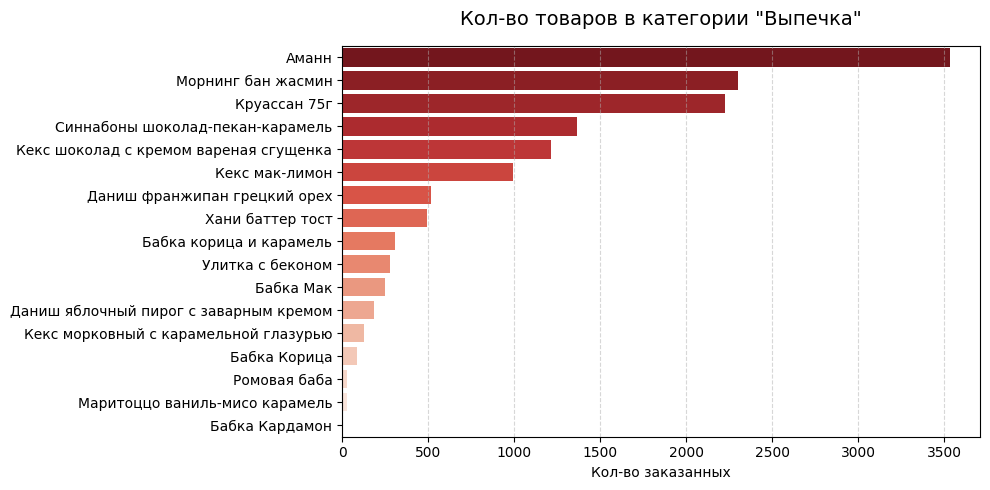

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


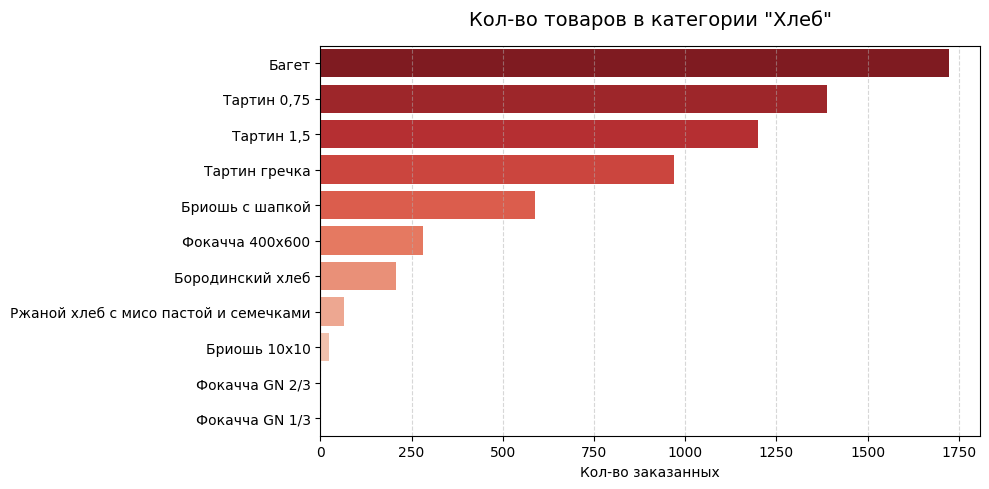

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


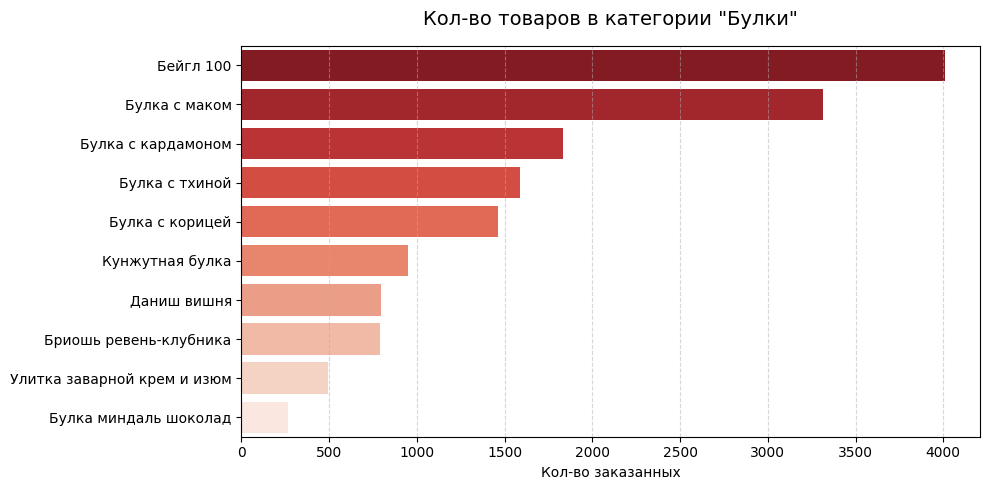

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


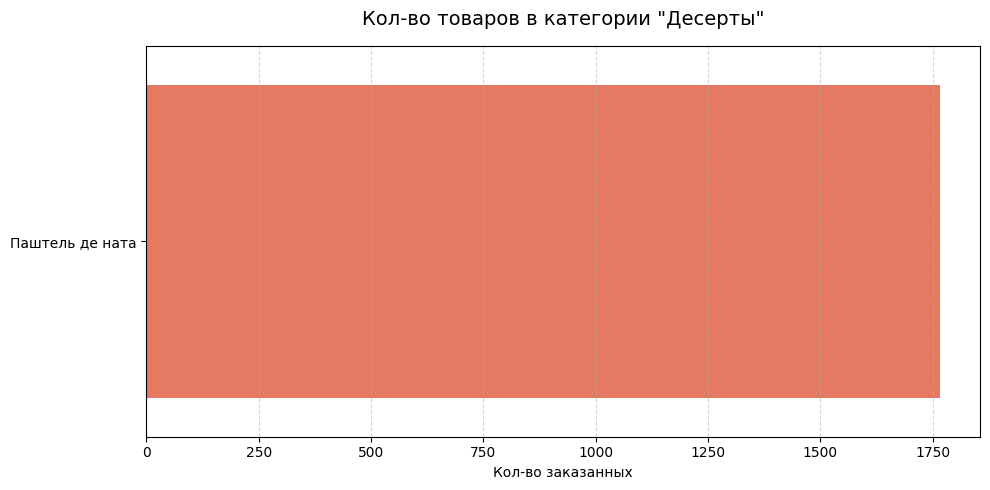

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


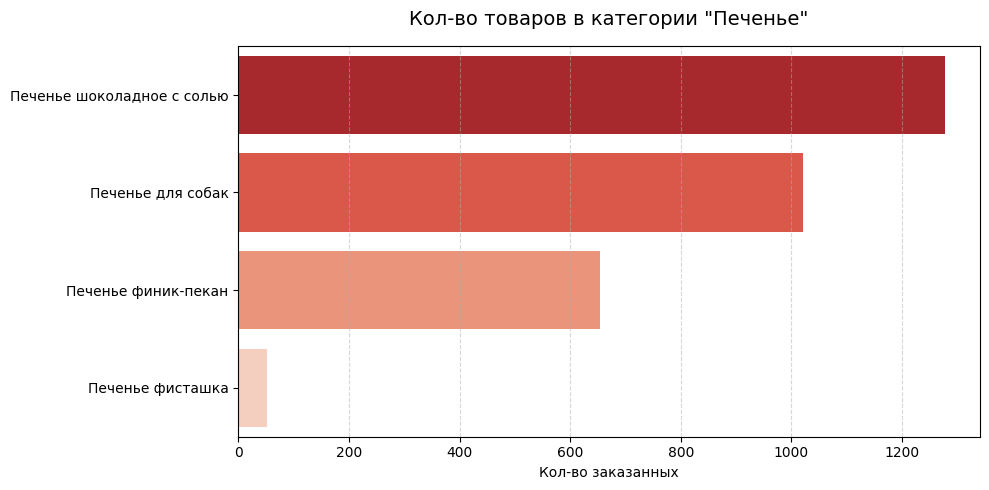

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


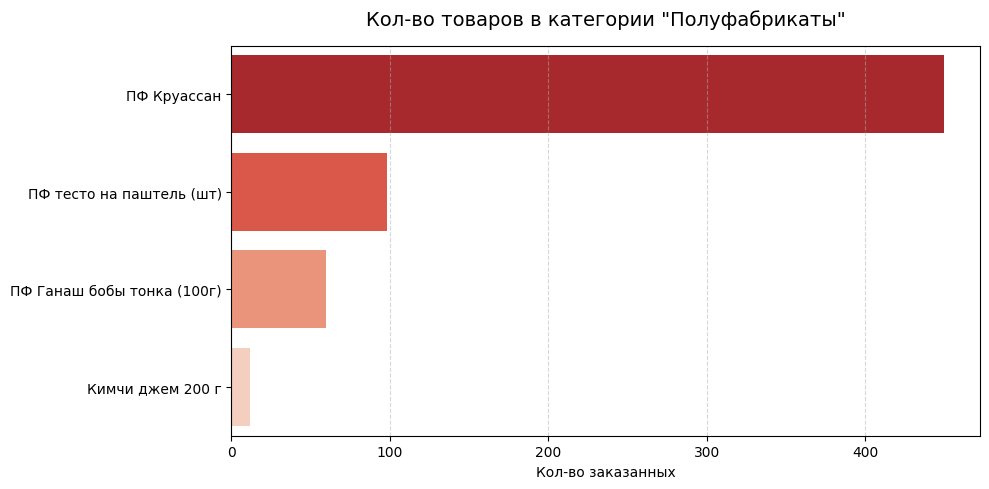

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


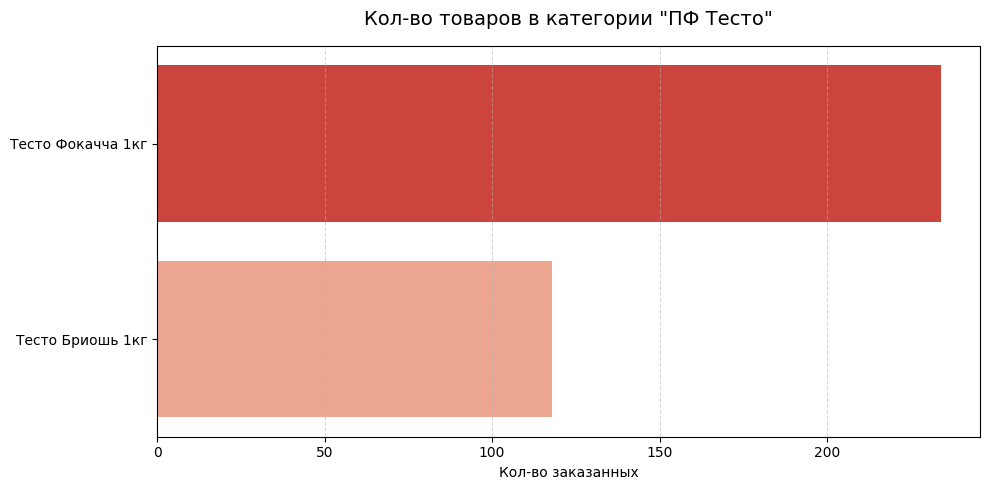

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


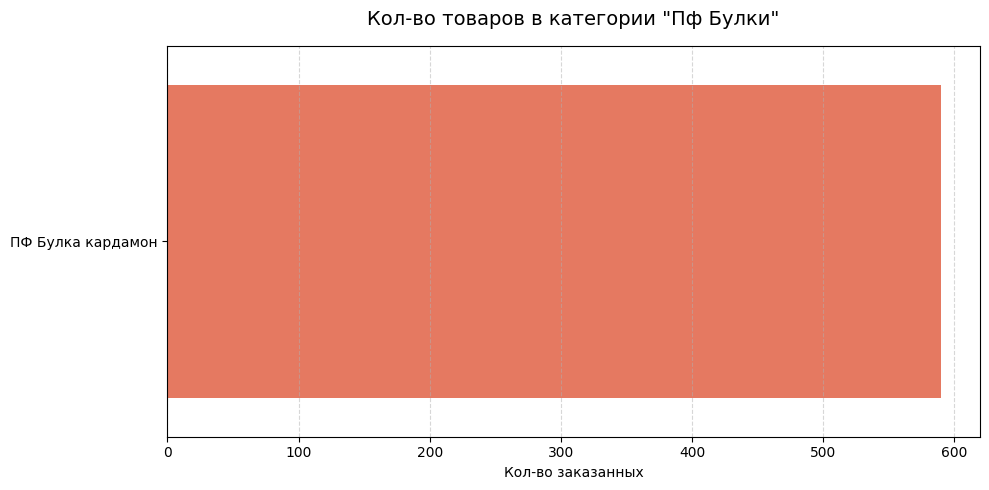

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


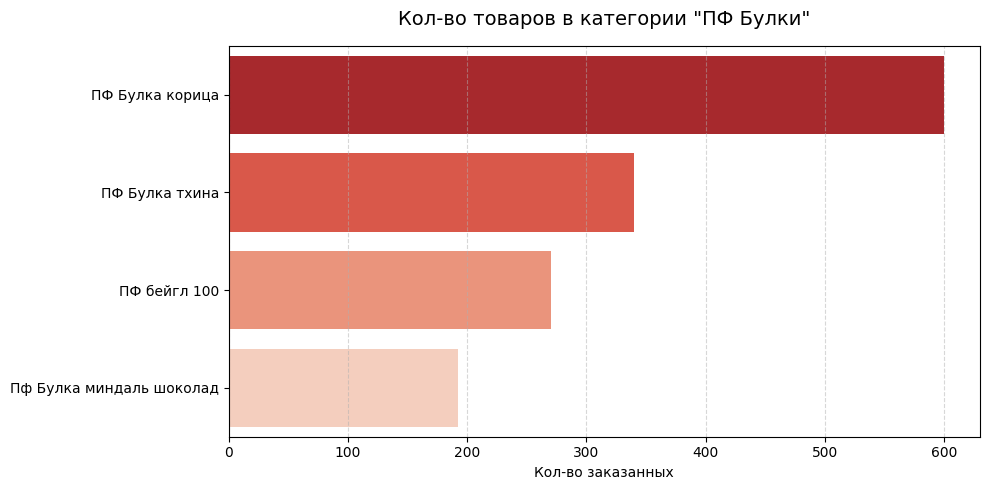

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


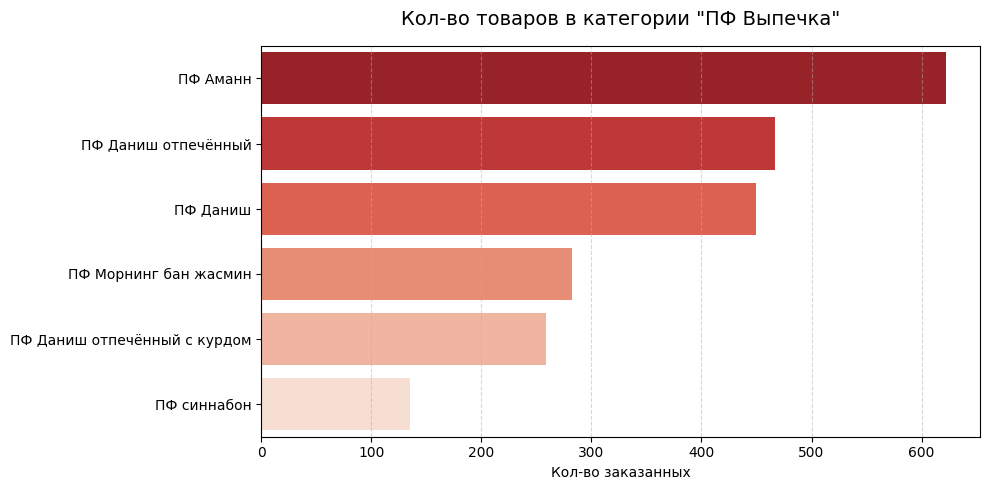

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_17776\625193360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


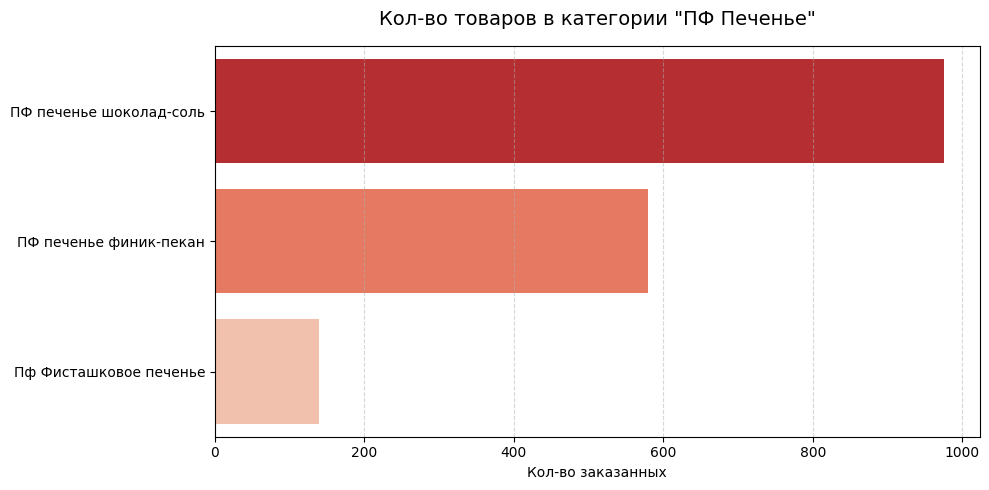

In [25]:
for category in df_2026['Category'].unique():
    plot_counts_in_category(category)

In [26]:
total_count = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()
top_3_per_cat = total_count.sort_values(['Category','Count'], ascending=[True, False]).groupby('Category').head(3)
pd.set_option('display.max_rows', None)
top_3_per_cat.reset_index(drop=True)

,Category,Name,Count
0,Булки,Бейгл 100,4009.0
1,Булки,Булка с маком,3317.0
2,Булки,Булка с кардамоном,1833.0
3,Выпечка,Аманн,3533.0
4,Выпечка,Морнинг бан жасмин,2300.0
5,Выпечка,Круассан 75г,2224.0
6,Десерты,Паштель де ната,1767.0
7,ПФ Булки,ПФ Булка корица,600.0
8,ПФ Булки,ПФ Булка тхина,340.0
9,ПФ Булки,ПФ бейгл 100,270.0


In [27]:
pd.reset_option('display.max_rows')

In [28]:
sales_2025 = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()
sales_2025.rename(columns={'Count': 'Sales_2026'}, inplace=True)

In [29]:
sales_2025.to_csv('sales_2026_ready.csv', index=False)

In [30]:
df_2026.to_csv('raw_2026.csv', index=False)

In [31]:
df_2026.head(10)

,Date,Name,Count,Point,Day_of_week,Category,Status
0,2026-06-01,Аманн,10.0,ЦЕХ_2026,Monday,Выпечка,Активный
1,2026-06-02,Аманн,10.0,ЦЕХ_2026,Tuesday,Выпечка,Активный
2,2026-06-03,Аманн,10.0,ЦЕХ_2026,Wednesday,Выпечка,Активный
3,2026-06-04,Аманн,12.0,ЦЕХ_2026,Thursday,Выпечка,Активный
4,2026-06-05,Аманн,20.0,ЦЕХ_2026,Friday,Выпечка,Активный
5,2026-06-06,Аманн,20.0,ЦЕХ_2026,Saturday,Выпечка,Активный
6,2026-06-07,Аманн,20.0,ЦЕХ_2026,Sunday,Выпечка,Активный
7,2026-06-08,Аманн,15.0,ЦЕХ_2026,Monday,Выпечка,Активный
8,2026-06-09,Аманн,15.0,ЦЕХ_2026,Tuesday,Выпечка,Активный
9,2026-06-10,Аманн,15.0,ЦЕХ_2026,Wednesday,Выпечка,Активный


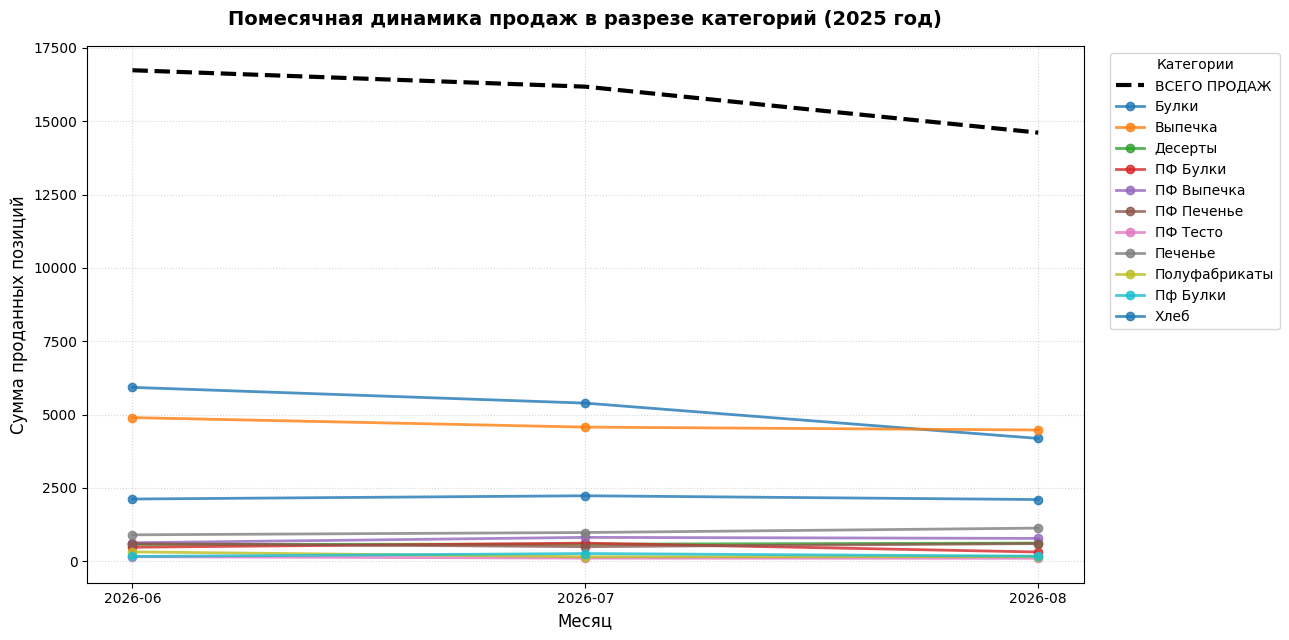

In [32]:
# 1. Приводим колонку Date к правильному формату даты
df_2026['Date'] = pd.to_datetime(df_2026['Date'])

# 2. Выделяем месяц в формате '2025-06'
df_2026['Month'] = df_2026['Date'].dt.to_period('M')

# 3. Считаем сумму Count для каждого месяца и чистой категории
monthly_sales = df_2026.groupby(['Month', 'Category'])['Count'].sum().reset_index()

# 4. Переводим месяц в строку, чтобы график корректно отобразил ось X
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# 5. Разворачиваем данные в матрицу для построения графиков
monthly_pivot = monthly_sales.pivot(index='Month', columns='Category', values='Count').fillna(0)

# ==========================================
# ВИЗУАЛИЗАЦИЯ ДИНАМИКИ
# ==========================================
plt.figure(figsize=(13, 6.5))

# Строим общую линию тренда по всем продажам
total_sales = monthly_pivot.sum(axis=1)
plt.plot(total_sales.index, total_sales.values, label='ВСЕГО ПРОДАЖ', color='black', linewidth=3, linestyle='--')

# Строим линии динамики для каждой категории
for category in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[category], label=category, linewidth=2, marker='o', alpha=0.8)

# Настройка внешнего вида
plt.title('Помесячная динамика продаж в разрезе категорий (2025 год)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Сумма проданных позиций', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

# Выносим легенду, чтобы она не перекрывала график
plt.legend(title='Категории', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


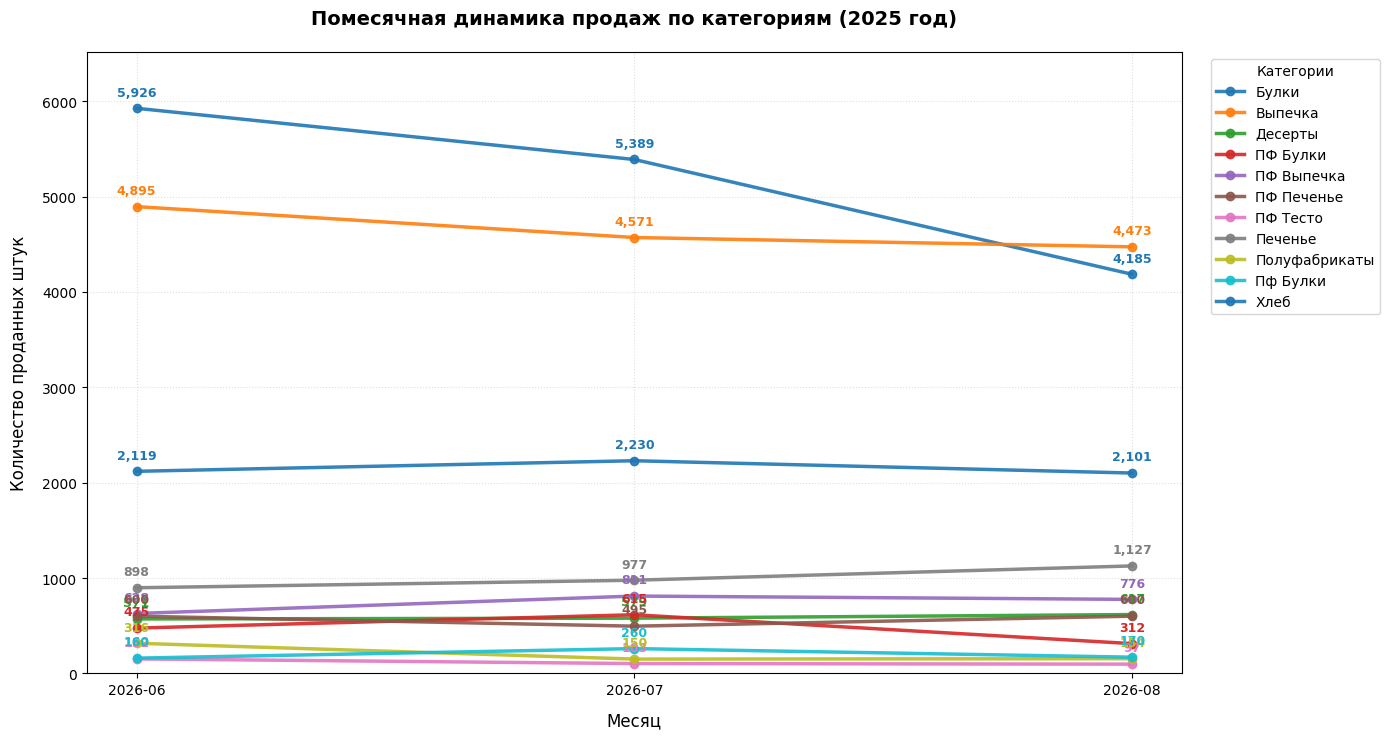

In [33]:
# ==========================================
# ВИЗУАЛИЗАЦИЯ ДИНАМИКИ С ЦИФРАМИ НАД ТОЧКАМИ
# ==========================================
plt.figure(figsize=(14, 7.5))

# Строим линии динамики для категорий
for category in monthly_pivot.columns:
    # Рисуем саму линию и точки
    line = plt.plot(monthly_pivot.index, monthly_pivot[category], label=category, linewidth=2.5, marker='o', alpha=0.9)
    color = line[0].get_color() # Берем цвет линии, чтобы текст был того же цвета
    
    # --- МАГИЯ: Добавляем цифры над каждой точкой ---
    for x, y in zip(monthly_pivot.index, monthly_pivot[category]):
        # Округляем до целых, так как это штуки продаж
        val = int(round(y)) 
        
        # Выводим текст чуть выше точки (xytext=(0, 7))
        plt.annotate(
            f'{val:,}', 
            xy=(x, y), 
            xytext=(0, 7), 
            textcoords='offset points', 
            ha='center', 
            va='bottom', 
            fontsize=9,
            color=color,
            weight='bold'
        )

# Настройка внешнего вида
plt.title('Помесячная динамика продаж по категориям (2025 год)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Месяц', fontsize=12, labelpad=10)
plt.ylabel('Количество проданных штук', fontsize=12, labelpad=10)

# Расширяем границы по оси Y, чтобы верхние цифры не упирались в край графика
plt.ylim(0, monthly_pivot.max().max() * 1.1) 

plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(title='Категории', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


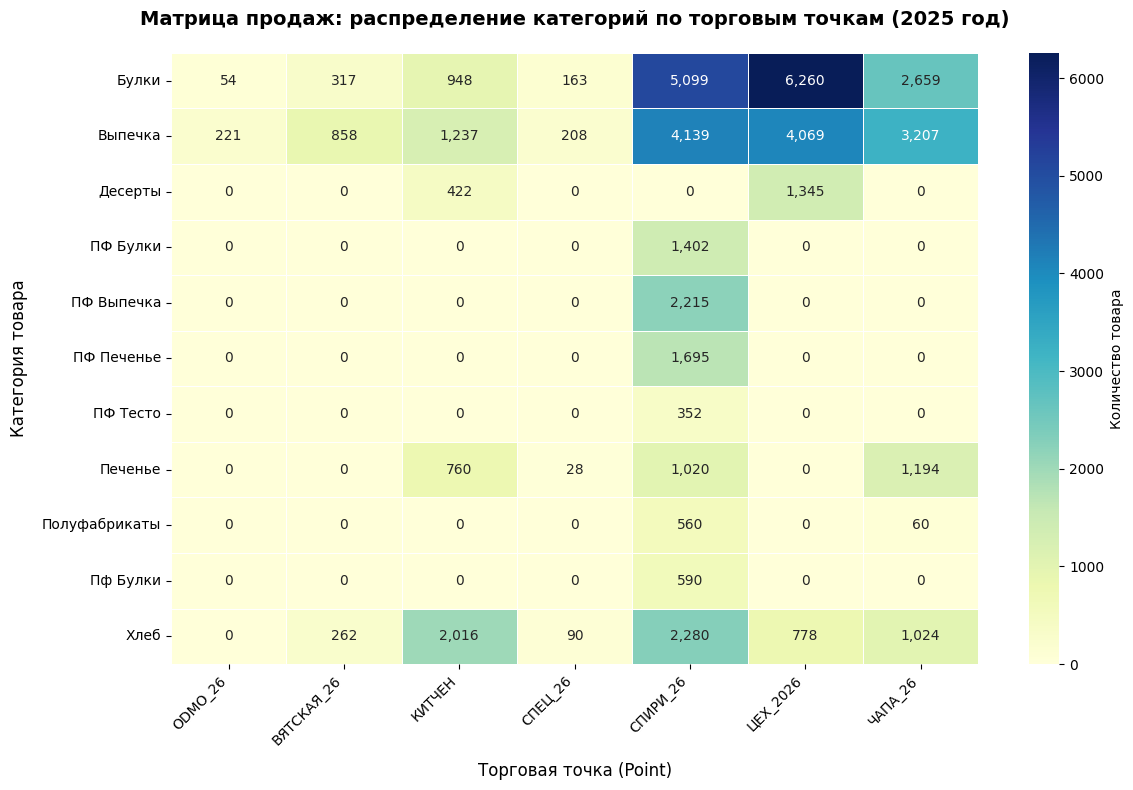

In [34]:
point_category_sales = df_2026.groupby(['Point', 'Category'])['Count'].sum().reset_index()

# Разворачиваем в матрицу: категории по строкам, торговые точки по столбцам
heatmap_pivot = point_category_sales.pivot(index='Category', columns='Point', values='Count').fillna(0)


# ==========================================
# ШАГ 2. ОТРИСОВКА ТЕПЛОВОЙ КАРТЫ (HEATMAP)
# ==========================================

plt.figure(figsize=(12, 8))

# Строим хитмап
# cmap='YlGnBu' — красивая палитра от желтого к глубокому синему
# annot=True — принудительно выводит точные цифры внутри каждой ячейки
# fmt=',.0f' — форматирует числа (выводит целые и разделяет тысячи)
sns.heatmap(
    heatmap_pivot, 
    annot=True, 
    fmt=',.0f', 
    cmap='YlGnBu', 
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'label': 'Количество товара'}
)

# Настройка оформления
plt.title('Матрица продаж: распределение категорий по торговым точкам (2025 год)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Торговая точка (Point)', fontsize=12, labelpad=10)
plt.ylabel('Категория товара', fontsize=12, labelpad=10)

# Поворачиваем подписи осей для идеальной читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()